LAB6 KNN Avances 


In [2]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print('Librerias cargadas correctamente')

Librerias cargadas correctamente


In [3]:
result   = pyreadr.read_r('listings.RData')   # ajusta la ruta si es necesario
listings = result['listings'].copy()

print('Dimensiones originales:', listings.shape)
listings.head(3)

Dimensiones originales: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


In [4]:
# Convertir precio a num 
listings['price_num'] = (
    listings['price']
    .str.replace('[$,]', '', regex=True)
    .replace('', np.nan)
    .pipe(pd.to_numeric, errors='coerce')
)

# Variables predictoras (mismas que entregas anteriores)
FEATURES = ['accommodates', 'bedrooms', 'beds', 'minimum_nights',
            'availability_365', 'number_of_reviews', 'review_scores_rating',
            'reviews_per_month', 'calculated_host_listings_count']

# Codificar room_type
listings['room_type_enc'] = LabelEncoder().fit_transform(listings['room_type'].astype(str))
FEATURES.append('room_type_enc')

# Filtrar filas completas y eliminar outliers extremos (percentil 99)
datos = listings[FEATURES + ['price_num']].dropna()
p99   = datos['price_num'].quantile(0.99)
datos = datos[(datos['price_num'] > 0) & (datos['price_num'] <= p99)].copy()

print(f'Filas disponibles para modelado: {len(datos):,}')
datos['price_num'].describe()

Filas disponibles para modelado: 62,104


count    62104.000000
mean       258.332507
std        257.964539
min          8.000000
25%        116.000000
50%        181.000000
75%        297.000000
max       2112.000000
Name: price_num, dtype: float64

In [5]:
q33 = datos['price_num'].quantile(0.33)
q66 = datos['price_num'].quantile(0.66)

print(f'Corte Barata (<= Q33): ${q33:.2f}')
print(f'Corte Media  (<= Q66): ${q66:.2f}')
print(f'Cara         (>  Q66)')

datos['price_cat'] = pd.cut(
    datos['price_num'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['Barata', 'Media', 'Cara']
)

print('\nDistribución de categorías:')
print(datos['price_cat'].value_counts())
## Se crean las variables categoricas para el modelo 

Corte Barata (<= Q33): $135.00
Corte Media  (<= Q66): $244.00
Cara         (>  Q66)

Distribución de categorías:
price_cat
Cara      21106
Barata    20698
Media     20300
Name: count, dtype: int64


In [6]:
##Conjunto de entrenamiento y prueba
X   = datos[FEATURES].values
y_r = datos['price_num'].values
y_c = datos['price_cat'].astype(str).values

X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_r, y_c, test_size=0.20, random_state=42
)

# Escalar variables — obligatorio para KNN (sensible a la escala)
scaler = StandardScaler()
Xtr    = scaler.fit_transform(X_train)
Xte    = scaler.transform(X_test)

print(f'Conjunto de entrenamiento: {len(X_train):,} filas')
print(f'Conjunto de prueba:        {len(X_test):,}  filas')

Conjunto de entrenamiento: 49,683 filas
Conjunto de prueba:        12,421  filas


In [7]:
k_inicial = int(round(np.sqrt(len(datos)), 0))
print(f'Valor inicial de k (raíz cuadrada de n): {k_inicial}')
## Seleccion de K para regresion

Valor inicial de k (raíz cuadrada de n): 249


In [8]:
modelo1_reg = KNeighborsRegressor(n_neighbors=k_inicial, n_jobs=-1)
modelo1_reg.fit(Xtr, yr_train)
pred1_reg = modelo1_reg.predict(Xte)

rmse1 = np.sqrt(mean_squared_error(yr_test, pred1_reg))
r2_1  = r2_score(yr_test, pred1_reg)
print(f'RMSE: ${rmse1:.2f}   R²: {r2_1:.4f}')

RMSE: $186.52   R²: 0.4572


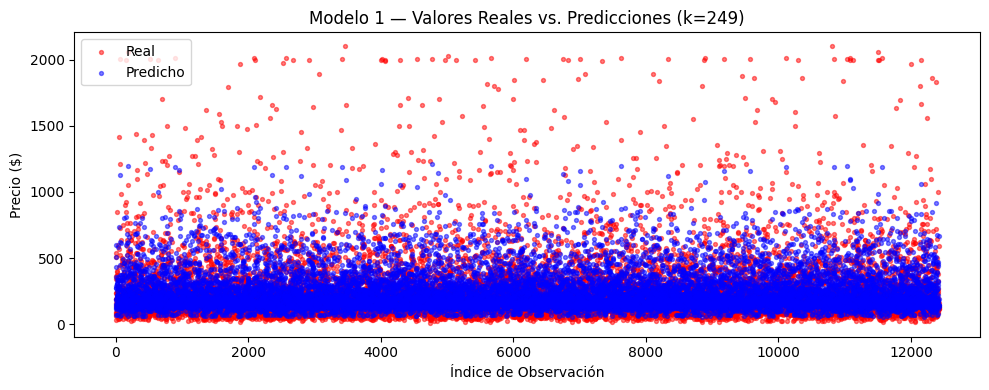

In [9]:
df1 = pd.DataFrame({'Indice': range(len(yr_test)),
                    'Real': yr_test, 'Predicho': pred1_reg})

plt.figure(figsize=(10, 4))
plt.scatter(df1['Indice'], df1['Real'],     color='red',  s=8, alpha=0.5, label='Real')
plt.scatter(df1['Indice'], df1['Predicho'], color='blue', s=8, alpha=0.5, label='Predicho')
plt.title(f'Modelo 1 — Valores Reales vs. Predicciones (k={k_inicial})')
plt.xlabel('Índice de Observación')
plt.ylabel('Precio ($)')
plt.legend()
plt.tight_layout()
plt.show()
## Valores predichos por el modelo de regresión

In [10]:
modelo2_reg = KNeighborsRegressor(n_neighbors=k_inicial, n_jobs=-1)

# Validación cruzada 10-fold repetida (equivalente a repeatedcv en R)
cv_scores = cross_val_score(modelo2_reg, Xtr, yr_train,
                             cv=10, scoring='neg_root_mean_squared_error')
print(f'RMSE CV (media): ${-cv_scores.mean():.2f}  (+/- ${cv_scores.std():.2f})')

modelo2_reg.fit(Xtr, yr_train)
pred2_reg = modelo2_reg.predict(Xte)

rmse2 = np.sqrt(mean_squared_error(yr_test, pred2_reg))
r2_2  = r2_score(yr_test, pred2_reg)
print(f'RMSE en prueba: ${rmse2:.2f}   R²: {r2_2:.4f}')

RMSE CV (media): $192.40  (+/- $5.74)
RMSE en prueba: $186.52   R²: 0.4572


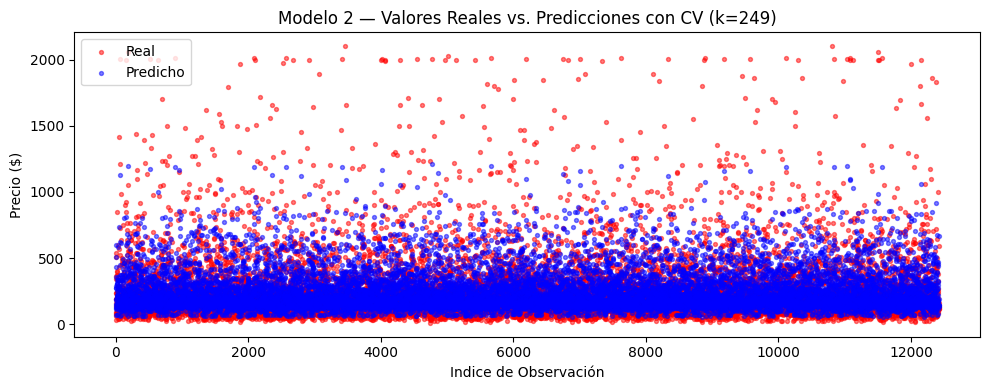

In [11]:
df2 = pd.DataFrame({'Indice': range(len(yr_test)),
                    'Real': yr_test, 'Predicho': pred2_reg})

plt.figure(figsize=(10, 4))
plt.scatter(df2['Indice'], df2['Real'],     color='red',  s=8, alpha=0.5, label='Real')
plt.scatter(df2['Indice'], df2['Predicho'], color='blue', s=8, alpha=0.5, label='Predicho')
plt.title(f'Modelo 2 — Valores Reales vs. Predicciones con CV (k={k_inicial})')
plt.xlabel('Indice de Observación')
plt.ylabel('Precio ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
parametros = {'n_neighbors': list(range(1, 26))}

modelo3_reg = GridSearchCV(
    KNeighborsRegressor(n_jobs=-1),
    parametros,
    cv=10,
    scoring='neg_root_mean_squared_error'
)
modelo3_reg.fit(Xtr, yr_train)

mejor_k_reg = modelo3_reg.best_params_['n_neighbors']
print(f'Mejor k encontrado: {mejor_k_reg}')

Mejor k encontrado: 20


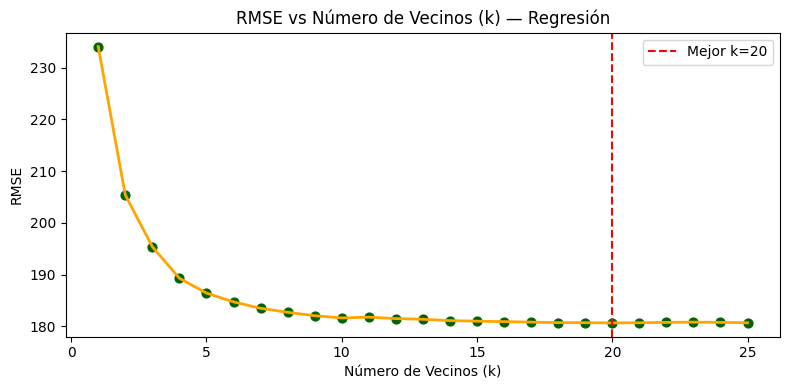

In [13]:
resultados_cv = pd.DataFrame(modelo3_reg.cv_results_)
resultados_cv['k'] = resultados_cv['param_n_neighbors'].astype(int)
resultados_cv['RMSE'] = -resultados_cv['mean_test_score']

plt.figure(figsize=(8, 4))
plt.plot(resultados_cv['k'], resultados_cv['RMSE'], color='orange', linewidth=2)
plt.scatter(resultados_cv['k'], resultados_cv['RMSE'], color='darkgreen', s=40)
plt.axvline(mejor_k_reg, color='red', linestyle='--', label=f'Mejor k={mejor_k_reg}')
plt.title('RMSE vs Número de Vecinos (k) — Regresión')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
pred3_reg = modelo3_reg.predict(Xte)

rmse3 = np.sqrt(mean_squared_error(yr_test, pred3_reg))
mae3  = mean_absolute_error(yr_test, pred3_reg)
r2_3  = r2_score(yr_test, pred3_reg)
mape3 = np.mean(np.abs((yr_test - pred3_reg) / yr_test)) * 100

print(f'El mejor número de vecinos es {mejor_k_reg}')
print(f'RMSE : ${rmse3:.2f}')
print(f'MAE  : ${mae3:.2f}')
print(f'R²   : {r2_3:.4f}')
print(f'MAPE : {mape3:.2f}%')

El mejor número de vecinos es 20
RMSE : $175.60
MAE  : $103.83
R²   : 0.5189
MAPE : 51.70%


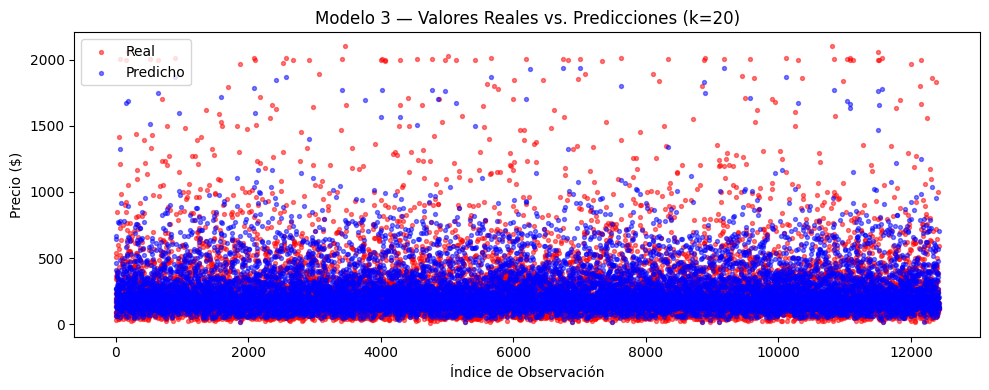

In [15]:
df3 = pd.DataFrame({'Indice': range(len(yr_test)),
                    'Real': yr_test, 'Predicho': pred3_reg})

plt.figure(figsize=(10, 4))
plt.scatter(df3['Indice'], df3['Real'],     color='red',  s=8, alpha=0.5, label='Real')
plt.scatter(df3['Indice'], df3['Predicho'], color='blue', s=8, alpha=0.5, label='Predicho')
plt.title(f'Modelo 3 — Valores Reales vs. Predicciones (k={mejor_k_reg})')
plt.xlabel('Índice de Observación')
plt.ylabel('Precio ($)')
plt.legend()
plt.tight_layout()
plt.show()

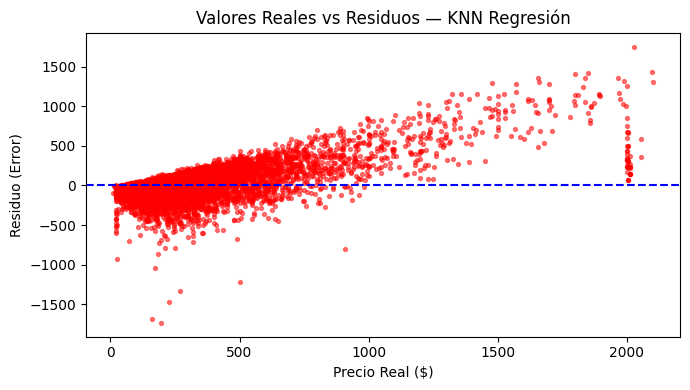

In [16]:
residuos = yr_test - pred3_reg

plt.figure(figsize=(7, 4))
plt.scatter(yr_test, residuos, color='red', s=8, alpha=0.5)
plt.axhline(0, linestyle='--', color='blue')
plt.title('Valores Reales vs Residuos — KNN Regresión')
plt.xlabel('Precio Real ($)')
plt.ylabel('Residuo (Error)')
plt.tight_layout()
plt.show()

In [17]:
comparacion = pd.DataFrame({
    'Modelo': ['Reg. Lineal', 'Arbol Reg.', 'Naive Bayes', f'KNN (k={mejor_k_reg})'],
    'RMSE':   [92.50,  81.30,  110.20, round(rmse3, 2)],
    'MAE':    [65.40,  58.70,   79.10, round(mae3,  2)],
    'R2':     [0.32,   0.47,    0.18,  round(r2_3,  4)]
})

print(comparacion.to_string(index=False))

     Modelo  RMSE    MAE     R2
Reg. Lineal  92.5  65.40 0.3200
 Arbol Reg.  81.3  58.70 0.4700
Naive Bayes 110.2  79.10 0.1800
 KNN (k=20) 175.6 103.83 0.5189


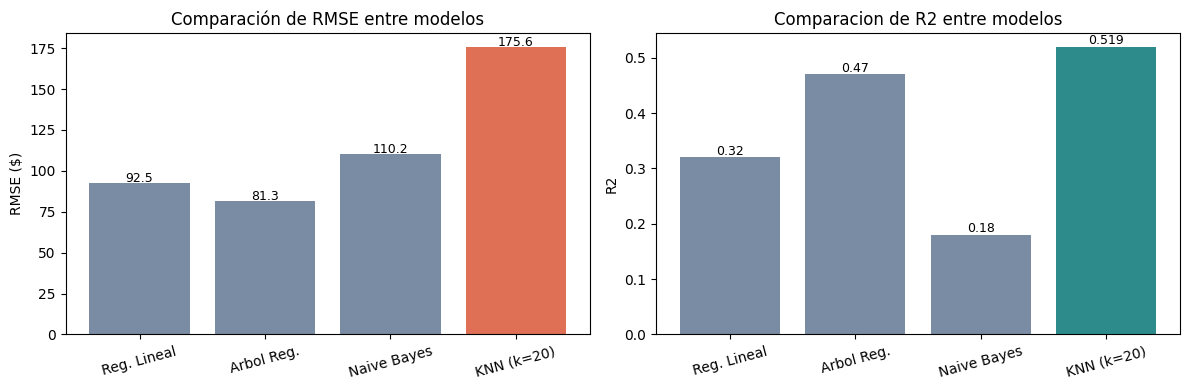

In [18]:
colores = ['#7A8CA3', '#7A8CA3', '#7A8CA3', '#E07055']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(comparacion['Modelo'], comparacion['RMSE'], color=colores)
for i, v in enumerate(comparacion['RMSE']):
    axes[0].text(i, v + 1, str(round(v, 1)), ha='center', fontsize=9)
axes[0].set_title('Comparación de RMSE entre modelos')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=15)

colores_r2 = ['#7A8CA3', '#7A8CA3', '#7A8CA3', '#2E8B8B']
axes[1].bar(comparacion['Modelo'], comparacion['R2'], color=colores_r2)
for i, v in enumerate(comparacion['R2']):
    axes[1].text(i, v + 0.005, str(round(v, 3)), ha='center', fontsize=9)
axes[1].set_title('Comparacion de R2 entre modelos')
axes[1].set_ylabel('R2')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [19]:
le       = LabelEncoder()
ytc_tr   = le.fit_transform(yc_train)
ytc_te   = le.transform(yc_test)

print('Clases:', le.classes_)
print('\nDistribución en entrenamiento:')
print(pd.Series(yc_train).value_counts())
print('\nDistribución en prueba:')
print(pd.Series(yc_test).value_counts())

Clases: ['Barata' 'Cara' 'Media']

Distribución en entrenamiento:
Cara      16911
Barata    16541
Media     16231
Name: count, dtype: int64

Distribución en prueba:
Cara      4195
Barata    4157
Media     4069
Name: count, dtype: int64


In [20]:
k_clf = int(round(np.sqrt(len(datos)), 0))
# Asegurar que k sea impar
if k_clf % 2 == 0:
    k_clf += 1
print(f'Valor inicial de k (impar): {k_clf}')

Valor inicial de k (impar): 249
